In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# os.environ["JAX_PLATFORM_NAME"] = "cpu"

In [3]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN, ResidualMLP
from jaxpm import camels, plotting, hpm, nn, graph

# print(jax.devices("gpu"))
print(jax.default_backend())

gpu


# configuration

In [4]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

# parts_per_dim = None
# mesh_per_dim = 256

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# i_snapshots = None
# i_snapshots = [-2,-1]
# i_snapshots = range(1, 33+8, 8)
i_snapshots = range(1, 33+4, 4)
# i_snapshots = np.arange(-4, 0, dtype=int)
# i_snapshots = np.arange(0, 4, dtype=int)

# i_snapshots = np.arange(10, 20, dtype=int)
# i_snapshots = np.arange(20, 24, dtype=int)

# CAMELS

In [5]:
out_dict = camels.load_CV_snapshots(
    "CV_0",
    # "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
    # CODE="Astrid",
    # CODE="IllustrisTNG",
)

cosmo = out_dict["cosmo"]
scales = out_dict["scales"]

dm_poss = out_dict["dm_poss"]
dm_vels = out_dict["dm_vels"]

gas_poss = out_dict["gas_poss"]
gas_vels = out_dict["gas_vels"]

# init_dm_pos = dm_poss[0]
# init_dm_vel = dm_vels[0]
# init_gas_pos = gas_poss[0]
# init_gas_vel = gas_vels[0]

Found matching catalogs
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  11%|█         | 1/9 [00:02<00:22,  2.82s/it]

Found 6 duplicate gas particle IDs


finding unique gas particle indices:  22%|██▏       | 2/9 [00:08<00:31,  4.54s/it]

Found 368 duplicate gas particle IDs


...

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 9/9 [00:48<00:00,  5.35s/it]


There are 15915287 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 9/9 [02:04<00:00, 13.82s/it]

Could not stack h_poss
Could not stack h_masss
Could not stack h_lens
Could not stack h_ids


In [6]:
# vali_dict = camels.load_CV_snapshots(
#     "CV_1",
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=i_snapshots,
#     return_hydro=True,
# )

In [7]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [8]:
@nnx.jit(static_argnames=("loss_fn",))
def train_step(model, optimizer, loss_fn):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

losses = []

In [9]:
# latent_init = cic_read(cic_paint(jnp.zeros(mesh_shape), gas_poss[0]), gas_poss[0])
# latent_init = jnp.expand_dims(latent_init, axis=-1)

# latent_init = jnp.ones((parts_per_dim**3,1))
# latent_init = jnp.ones((parts_per_dim**3,8))
# latent_init = np.random.normal(loc=1.0, scale=0.01, size=(parts_per_dim**3,4))

latent_init = None

In [10]:
edges = graph.get_edges(gas_poss, scales, k=4)

def solve_ode_diffrax(model, architecture, with_latent=True):
    # if with_latent:
    #     y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init)
    # else:
    #     y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])

    # y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init)
    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])
    
    res = diffeqsolve(
            terms=ODETerm(hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gravity_model=None, pressure_model=model, gas_architecture=architecture, precomputed_edges=edges)),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            # dt0=0.02,
            dt0=0.01,
            y0=y0,
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
            # adjoint=diffrax.BacksolveAdjoint(),
        )
    res = res.ys

    return res

In [11]:
# solve_ode_diffrax(model, architecture);

# loss

### CAMELS ground truth

In [12]:
# per-particle reference
ref_pos = jnp.stack(gas_poss, axis=0)
ref_vel = jnp.stack(gas_vels, axis=0)

# # velocity
# vel_mean_ref = jax.vmap(
#     jax.vmap(
#         cic_paint, 
#         in_axes=(None,0,0)
#     ),
#     in_axes=(None,None,-1), out_axes=-1,
# )(jnp.zeros(mesh_shape), ref_pos, ref_vel / ref_N[..., jnp.newaxis])

# ref_vel_mean = jax.vmap(
#     jax.vmap(
#         cic_read, 
#         in_axes=(0,0)
#     ),
#     in_axes=(-1,None), out_axes=-1,
# )(vel_mean_ref, ref_pos)

# ref_vel_disp = jnp.sum((ref_vel_mean - ref_vel) ** 2, axis=-1)

# field-level reference
gas_mass = cosmo.Omega_b / (cosmo.Omega_b + cosmo.Omega_c)
ref_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# power spectrum reference
vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
_, ref_cls = vpower_spectrum(ref_rho)

vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

In [13]:
# res = solve_ode_diffrax(model, architecture)
# gas_poss = res[2]
# res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# kbins, res_cross = vcross_correlation(res_rho)

In [14]:
# k = kbins[0]
# k_min = k[0]
# k_cutoff = k[int(0.2*len(k))]
# k_weights = jnp.exp(-(k - k[0]) / k_cutoff)

# plt.plot(k, k_weights)
# # plt.ylim(0,1)
# plt.xscale("linear")
# plt.yscale("log")
# plt.show()

# plt.plot(k, res_cross[-1], label="original")
# plt.plot(k, k_weights * res_cross[-1], label="weighted")
# plt.xscale("linear")
# plt.yscale("log")
# plt.legend()
# plt.show()

### particle-level

In [15]:
# def particle_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]%mesh_per_dim
#     gas_vels = res[3]

#     pos_loss = jnp.sum((gas_poss - ref_pos)**2, axis=-1)
#     pos_loss = jnp.where(pos_loss < mesh_per_dim//2, pos_loss, 0.)
#     # pos_loss *= jnp.expand_dims(scales, axis=1)
#     pos_loss = jnp.mean(pos_loss)

#     vel_loss = jnp.sum((gas_vels - ref_vel)**2, axis=-1)
#     vel_loss = jnp.where(vel_loss < mesh_per_dim//2, vel_loss, 0.)
#     # vel_loss *= jnp.expand_dims(scales, axis=1)
#     vel_loss = jnp.mean(vel_loss)

#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     _, res_cls = vpower_spectrum(res_rho)
#     cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))

#     # _, res_cross = vcross_correlation(res_rho)
#     # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

#     # return pos_loss + 0.01 * vel_loss + 0.01 * cl_loss
#     # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
#     # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss + 1 * cross_loss
#     # return cl_loss
#     # return cross_loss
#     # return cl_loss
#     # return pos_loss + 0.01 * vel_loss
#     # return pos_loss + 0.01 * vel_loss
#     # return pos_loss + vel_loss
#     return pos_loss


In [16]:
# def particle_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]
#     gas_vels = res[3]

#     delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
#     pos_loss = jnp.sum(delta_pos**2, axis=-1)
#     # pos_loss = jnp.sum(huber_loss(delta_pos), axis=-1)
#     pos_loss = jnp.mean(pos_loss)

#     # vel_disp = jnp.std(gas_vels, axis=0)
#     # vel_loss = jnp.sum(((gas_vels - ref_vel) / (vel_disp + 1e-5))**2, axis=-1)
#     # vel_loss = jnp.mean(vel_loss)

#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     _, res_cls = vpower_spectrum(res_rho)
#     cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))

#     # _, res_cross = vcross_correlation(res_rho)
#     # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

#     return pos_loss + 0.1 * cl_loss
#     # return pos_loss + 0.01 * vel_loss + 0.01 * cl_loss
#     # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
#     # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss + 1 * cross_loss
#     # return cl_loss
#     # return cross_loss
#     # return cl_loss
#     # return pos_loss + 0.01 * vel_loss
#     # return pos_loss + 0.01 * vel_loss
#     # return pos_loss + vel_loss
#     # return pos_loss


In [17]:
# def particle_loss_fn(model, architecture, huber=False, pos_dead_zone=False, eps=1e-8):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]
#     gas_vels = res[3]

#     delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
#     if huber:
#         pos_loss = jnp.sum(huber_loss(delta_pos), axis=-1)
#     else:
#         pos_loss = jnp.sum(delta_pos**2, axis=-1)
#     if pos_dead_zone:
#         pos_loss = jnp.where(jnp.sqrt(pos_loss) < 1/mesh_per_dim, 0.0, pos_loss)

#     # pos_loss = jnp.where(jax.lax.is_finite(pos_loss), pos_loss, 0.0)
#     pos_loss = jnp.mean(pos_loss)
#     # print(pos_loss)

#     # vel_loss = jnp.sum(((gas_vels - ref_vel) / (jnp.sqrt(ref_vel_disp[...,np.newaxis]) + 1e-5))**2, axis=-1)
#     # vel_loss = jnp.sum((gas_vels - ref_vel)**2, axis=-1)
#     # vel_loss = jnp.mean(vel_loss)
#     # print(vel_loss)
    
#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     kbins, res_cls = vpower_spectrum(res_rho)

#     k = kbins[0]
#     k_min, k_cutoff = k[0], k[int(0.2*len(k))]
#     k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

#     cl_loss = jnp.sum(((res_cls/(ref_cls + eps) - 1)*k_weights)**2, axis=-1)

#     # cl_loss = jnp.where(jax.lax.is_finite(cl_loss), cl_loss, 0.0)
#     cl_loss = jnp.mean(cl_loss)

#     # cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))
#     # print(cl_loss)
    
#     # _, res_cross = vcross_correlation(res_rho)
#     # cross_loss = jnp.sum(((res_cross/jnp.sqrt(ref_cls * res_cls) - 1) * k_weights)**2)
#     # # cross_loss = jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2)
#     # cross_loss = jnp.mean(cross_loss)

#     # dm_force, gas_force, d_gas_latent = jax.vmap(
#     #     lambda scale, dm_p, gas_p, gas_v, gas_l: hpm.hpm_forces(
#     #         mesh_per_dim, cosmo, scale, dm_p, gas_p, 
#     #         gas_model=model, gas_architecture=architecture,
#     #         gas_vel=gas_v, gas_latent=gas_l,
#     #     ),
#     #     in_axes=(0, 0, 0, 0, 0)
#     # )(scales, res[0], res[2], res[3], res[4])  

#     # corr_matrix = jax.vmap(lambda array: jnp.corrcoef(array, rowvar=False), in_axes=0)(d_gas_latent)
#     # latent_loss = jnp.square(corr_matrix - jnp.expand_dims(jnp.eye(corr_matrix.shape[1]), axis=0))
#     # latent_loss = jnp.mean(latent_loss)
#     # print(latent_loss)
    
#     # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))
#     # print(cross_loss)

#     # return pos_loss
#     # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
#     return pos_loss + 0.1 * cl_loss
#     # return pos_loss + 0.1 * cl_loss + 0.1 * cross_loss + latent_loss
#     # return cross_loss
#     # return pos_loss + cl_loss + cross_loss

In [18]:
# def particle_loss_fn(model, architecture, huber=True, pos_dead_zone=True):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]
#     gas_vels = res[3]

#     delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
#     if huber:
#         pos_loss = jnp.sum(huber_loss(delta_pos), axis=-1)
#     else:
#         pos_loss = jnp.sum(delta_pos**2, axis=-1)
#     if pos_dead_zone:
#         pos_loss = jnp.where(jnp.sqrt(pos_loss) < 1/mesh_per_dim, 0.0, pos_loss)
#     pos_loss = jnp.mean(pos_loss)
    
#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     kbins, res_cls = vpower_spectrum(res_rho)

#     k = kbins[0]
#     k_min, k_cutoff = k[0], k[int(0.2*len(k))]
#     k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

#     cl_loss = jnp.sum(((res_cls/ref_cls - 1)*k_weights)**2, axis=-1)
#     cl_loss = jnp.mean(cl_loss)

#     return pos_loss + 0.1 * cl_loss


In [57]:
def particle_loss_fn(model, architecture, eps=1e-8):
    res = solve_ode_diffrax(model, architecture)
    gas_poss = res[2]
    gas_vels = res[3]

    delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_pos**2, axis=-1)

    # pos_loss /= jnp.maximum(jnp.mean(pos_loss, axis=1, keepdims=True), eps)
    pos_loss /= jnp.maximum(scales[:, jnp.newaxis]**3, eps)
    
    pos_loss = jnp.mean(pos_loss)
    
    res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    kbins, res_cls = vpower_spectrum(res_rho)

    k = kbins[0]
    k_min, k_cutoff = k[0], k[int(0.2*len(k))]
    k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

    cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)

    # cl_loss /= jnp.mean(cl_loss, axis=0, keepdims=True)
    # cl_loss /= jnp.maximum(scales[:,jnp.newaxis]**2, eps)
    
    cl_loss = jnp.mean(cl_loss)

    return pos_loss + 0.1 * cl_loss
    # return pos_loss
    # return cl_loss



In [55]:
eps = 1e-8

res = solve_ode_diffrax(model, architecture)
gas_poss = res[2]
gas_vels = res[3]

delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
pos_loss = jnp.sum(delta_pos**2, axis=-1)

res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
kbins, res_cls = vpower_spectrum(res_rho)

k = kbins[0]
k_min, k_cutoff = k[0], k[int(0.2*len(k))]
k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


In [56]:
cl_loss.shape

(9,)

In [53]:
jnp.mean(pos_loss, axis=1)/scales**3

Array([ 0.       ,  6.7302866, 11.730371 , 17.784252 , 24.30623  ,
       27.544445 , 25.916296 , 21.35677  , 15.899165 ], dtype=float32)

In [20]:
# res = solve_ode_diffrax(model, architecture)

# dm_force, gas_force, d_gas_latent = jax.vmap(
#     lambda scale, dm_p, gas_p, gas_v, gas_l: hpm.hpm_forces(
#         mesh_per_dim, cosmo, scale, dm_p, gas_p, 
#         gas_model=model, gas_architecture=architecture,
#         gas_vel=gas_v, gas_latent=gas_l,
#     ),
#     in_axes=(0, 0, 0, 0, 0)
# )(scales, res[0], res[2], res[3], res[4])  

# corr_matrix = jax.vmap(lambda array: jnp.corrcoef(array, rowvar=False), in_axes=0)(d_gas_latent)
# latent_loss = jnp.square(corr_matrix - jnp.expand_dims(jnp.eye(corr_matrix.shape[1]), axis=0))
# latent_loss = jnp.mean(latent_loss)


In [21]:
# particle_loss_fn(model, architecture)

In [22]:
# res = solve_ode_diffrax(model, architecture)
# gas_poss = res[2]
# gas_vels = res[3]

In [23]:
# plt.hist((gas_vels - ref_vel).ravel(), bins=100, log=True);

In [24]:
# temp = (gas_vels - ref_vel)/(ref_vel_disp[...,np.newaxis] + 1e-5)
# plt.hist(temp.ravel(), bins=50, log=True);

### field-level

In [25]:
# def field_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]%mesh_per_dim

#     rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
        
#     eps = 1e-5
#     # rho_loss = jnp.mean((jnp.log1p(rho + eps) - jnp.log1p(ref_rho + eps))**2)
#     # rho_loss = jnp.mean((jnp.log10(rho - ref_rho + eps))**2)
    
#     rho_loss = jnp.mean(jnp.sum((rho - ref_rho)**2, axis=(1,2,3)))

#     # _, res_cls = vpower_spectrum(res_rho)
#     # cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))
    
#     return rho_loss
#     # return rho_loss + 0.1 * cl_loss


In [60]:
def field_loss_fn(model, architecture):
    res = solve_ode_diffrax(model, architecture)
    gas_poss = res[2]%mesh_per_dim
    
    rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    
    eps = 1e-8
    log_rho = jnp.log10(rho + eps)
    log_ref_rho = jnp.log10(ref_rho + eps)
    # log_loss = jnp.mean(jnp.sum((log_rho - log_ref_rho)**2, axis=(1,2,3)))
    log_loss = jnp.mean((log_rho - log_ref_rho)**2)
        
    return log_loss

# architecture

### MLP

In [61]:
if latent_init is None:
    latent_dim = 0
else:
    latent_dim = latent_init.shape[-1]

model = MLP(
    d_in=5 + latent_dim,
    d_out=1 + latent_dim, 
    d_hidden=64, 
    # d_hidden=128, 
    n_hidden=4, 
    # dropout_rate=0.01,
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    norm_type="batch",
    # norm_type="layer",
)
architecture = "mlp"

In [62]:
# if latent_init is None:
#     latent_dim = 0
# else:
#     latent_dim = latent_init.shape[-1]

# model = ResidualMLP(
#     d_in=5 + latent_dim,
#     d_out=1 + latent_dim, 
#     d_hidden=64, 
#     # d_hidden=128, 
#     n_hidden=4, 
#     # dropout_rate=0.01,
#     dropout_rate=0.0,
#     rngs=nnx.Rngs(0),
#     norm_type="batch",
#     # norm_type="layer",
# )
# architecture = "mlp"

In [63]:
# model = ResidualMLP(
#     d_in=5 + latent_dim,
#     d_out=1 + latent_dim, 
#     d_hidden=64, 
#     # d_hidden=128, 
#     n_hidden=4, 
#     # dropout_rate=0.01,
#     dropout_rate=0.0,
#     rngs=nnx.Rngs(0),
#     norm_type="batch",
#     # norm_type="layer",
# )
# architecture = "mlp"

In [64]:
# model = ResidualMLP(
#         d_in=5,
#         d_out=1,
#         d_hidden=64,
#         # d_hidden=128,
#         n_blocks=2,
#         rngs=nnx.Rngs(0),
#         dropout_rate=0.0,
#         activation=jax.nn.relu,
#         norm_type="batch",
#         # norm_type="layer",
# )
# architecture = "mlp"

In [65]:
# nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model, gas_architecture=architecture)

# nn_res = diffeqsolve(
#         terms=ODETerm(nn_ode),
#         solver=LeapfrogMidpoint(),
#         t0=scales[0],
#         t1=scales[-1],
#         dt0=0.01,
#         y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
#         # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
#         saveat=SaveAt(ts=scales),
#         max_steps=100,
#         stepsize_controller=ConstantStepSize(),
#         # adjoint=diffrax.BacksolveAdjoint(),
# )

# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
# # nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

### CNN

In [66]:
# model = CNN(
#     d_in=4 + latent_dim, 
#     d_out=1,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(3, 3, 3),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# architecture = "cnn"

In [67]:
# model = nn.ResNet3D(
#         d_in=4,
#         d_hidden=8,
#         d_out=1,
#         num_blocks=1,
#         rngs=nnx.Rngs(0),
#         kernel_size=(3, 3, 3),
#         strides=1,
# )
# architecture = "cnn"

### MLP + CNN

In [68]:
# if latent_init is None:
#     latent_dim = 0
# else:
#     latent_dim = latent_init.shape[-1]

# mlp = MLP(
#     d_in=5 + latent_dim,
#     d_out=8, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=4 + latent_dim, 
#     d_out=8,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(3, 3, 3),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1 + latent_dim, 
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

In [69]:
# if latent_init is None:
#     latent_dim = 0
# else:
#     latent_dim = latent_init.shape[-1]

# mlp = MLP(
#     d_in=5 + latent_dim,
#     d_out=16, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=4 + latent_dim, 
#     d_out=16,
#     d_hidden=16,
#     n_hidden=1,
#     kernel_size=(5, 5, 5),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1 + latent_dim, 
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

### GNN

on the fly

In [70]:
# with_latent = False

# model = AttentionGNN(
#     d_node=5 + with_latent,
#     d_edge=1,
#     d_query=32,
#     n_hidden=4,
#     d_out=1 + with_latent,
#     rngs=nnx.Rngs(0),
# )

# architecture = "gnn"

# training

In [71]:
total_steps = 200
learning_rate = 1e-3
# learning_rate = 1e-4
# learning_rate = 1e-5
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-4, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
# learning_rate = optax.warmup_cosine_decay_schedule(
#     init_value=1e-5,
#     peak_value=1e-4,
#     end_value=1e-5,
#     warmup_steps=total_steps//5,
#     decay_steps=total_steps - total_steps//5, 
# )
clip_norm = 1

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate, eps=1e-5)
    )
)

losses = []
loss_fn = lambda model: particle_loss_fn(model, architecture)
# loss_fn = lambda model: field_loss_fn(model, architecture)

  0%|          | 0/200 [00:00<?, ?it/s]

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


2025-04-17 22:06:45.213249: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %negate.61 = f32[9,262144,3]{2,1,0} negate(f32[9,262144,3]{2,1,0} %constant.218)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-04-17 22:06:48.380607: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 5.167424754s
Constant folding an instruction is taking > 2s:

  %negate.61 = f32[9,262144,3]{2,1,0} negate(f32[9,262144,3]{2,1,0} %constant.218)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some gu

[None]

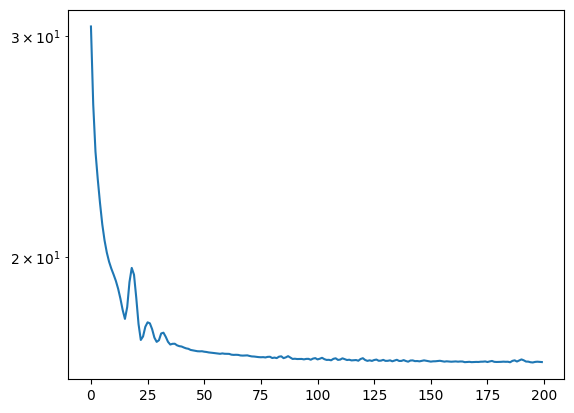

In [72]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    loss = train_step(model, optimizer, loss_fn)

    losses.append(loss)
    pbar.set_description(f"Loss: {loss:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

### checkpointing

In [39]:
# see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v1_late_time.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v2.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_illustris_v1.jx")
checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v3_full.jx")
checkpointer = ocp.StandardCheckpointer()
print(os.getcwd())

/cluster/home/athomsen/flatiron/repos/JaxPM/dev/hpm/sims


In [47]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [41]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

In [73]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)

og_res = diffeqsolve(
        terms=ODETerm(og_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

dark matter and gas
dark matter and gas
dark matter and gas


In [74]:
nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, pressure_model=model, gas_architecture=architecture)

nn_res = diffeqsolve(
        terms=ODETerm(nn_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 9/9 [00:05<00:00,  1.67it/s]


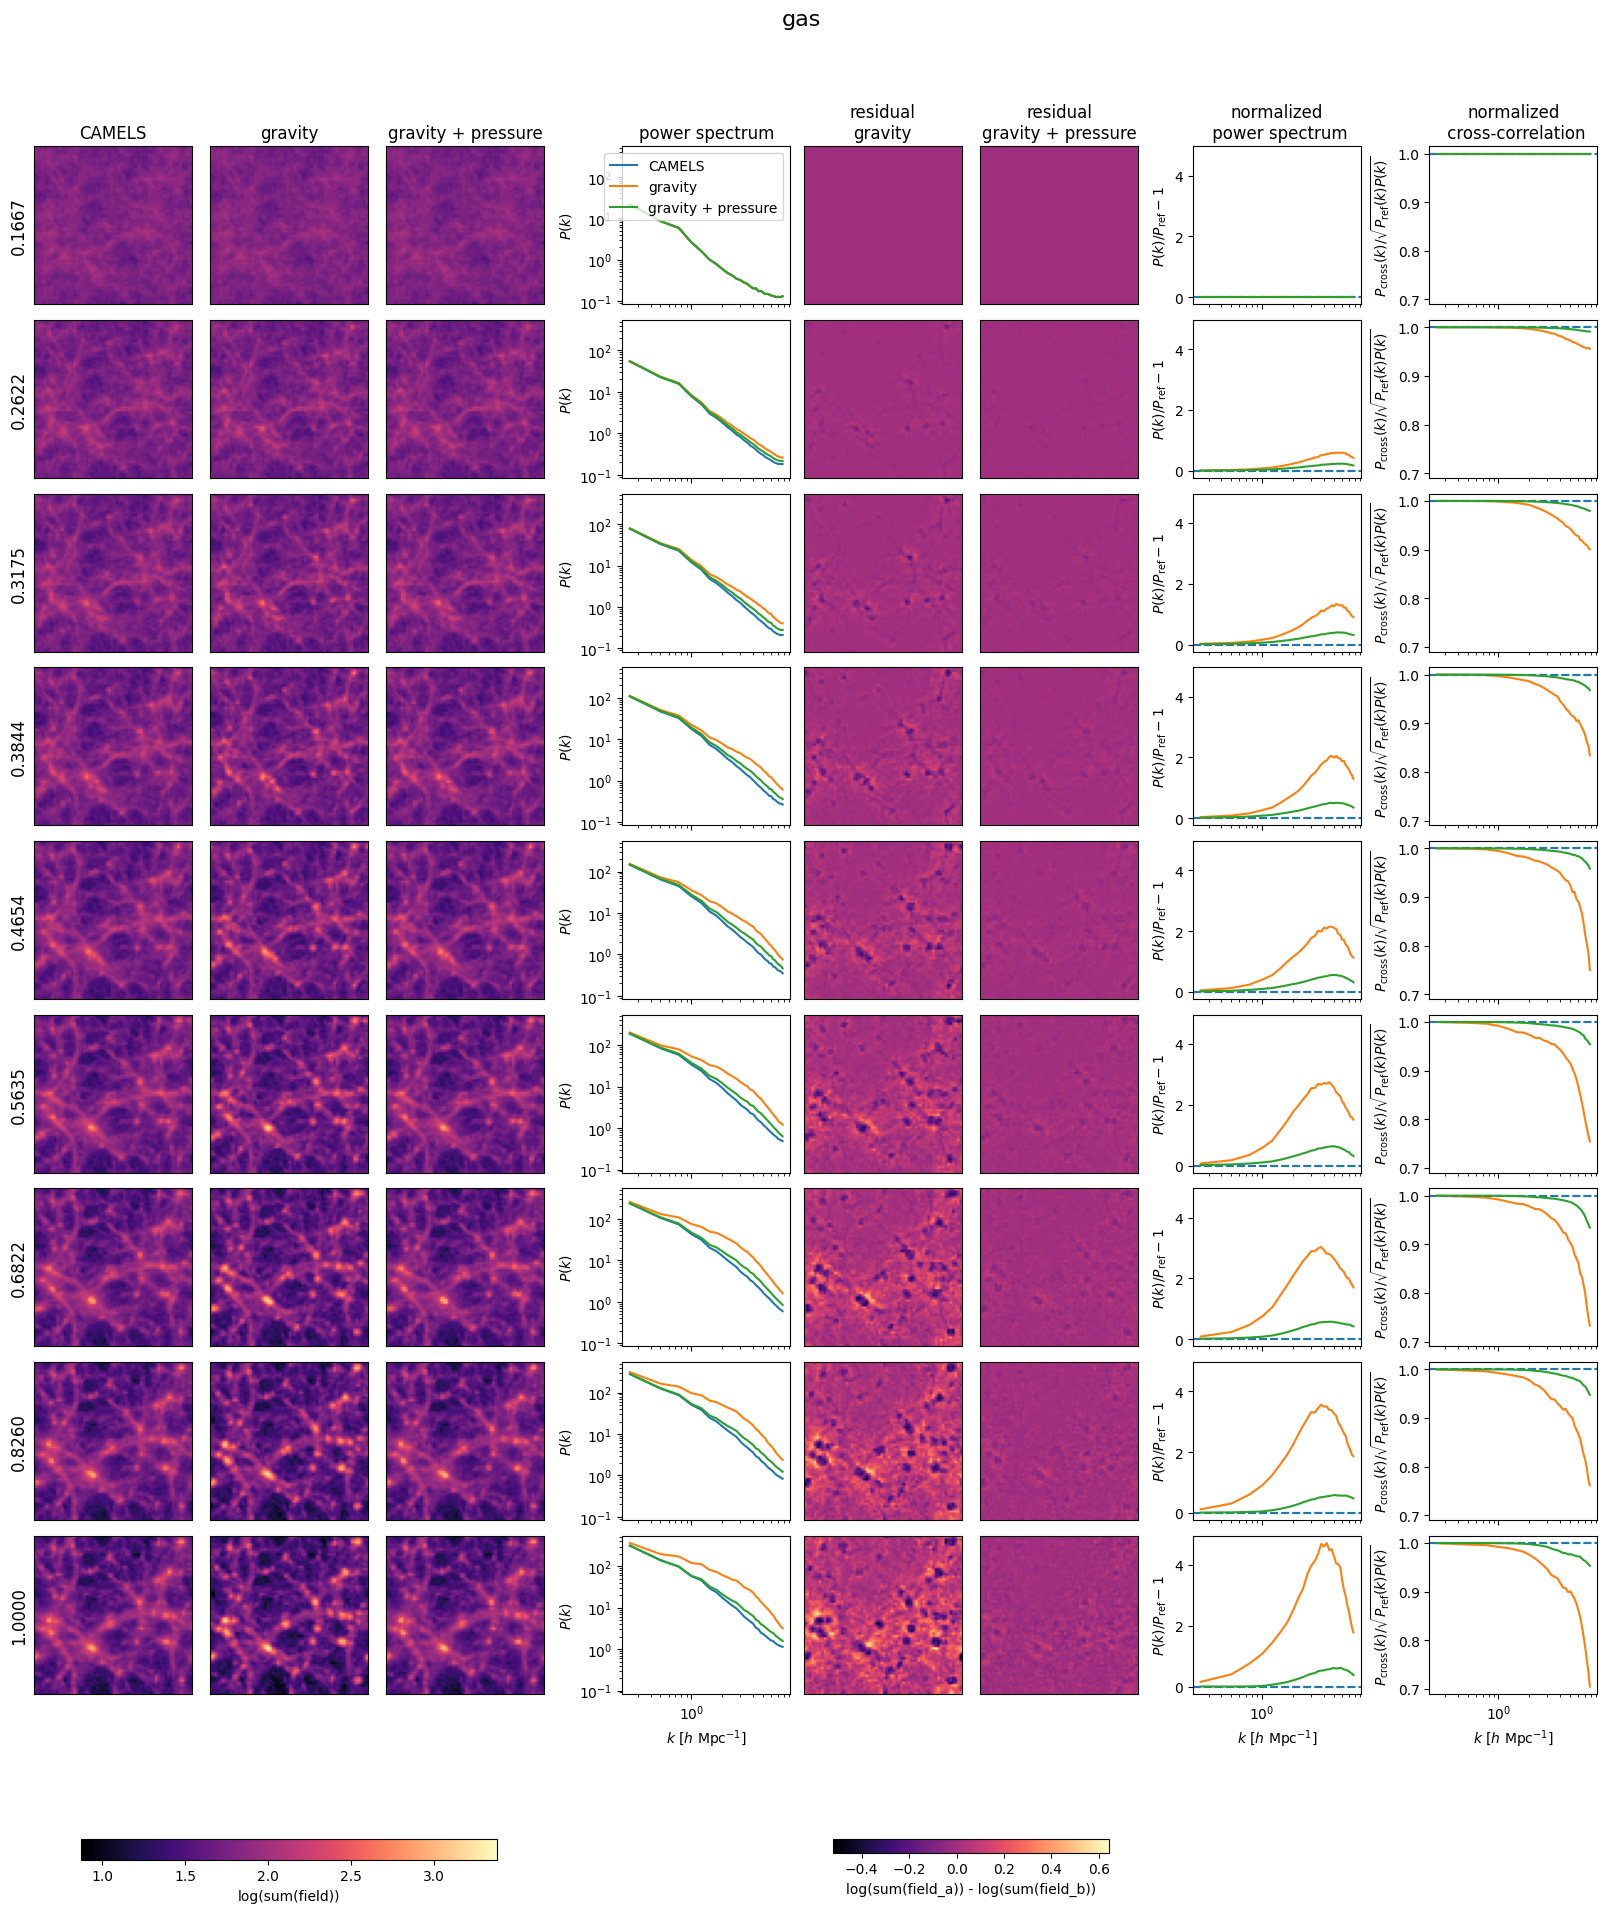

In [75]:
with jax.default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        jnp.stack([gas_poss, og_gas_poss, nn_gas_poss], axis=0), 
        title="gas",
        col_titles=["CAMELS", "gravity", "gravity + pressure"],
        include_pk=True,
        include_reference=True,
    )

### latent

In [45]:
from jax import default_device

In [46]:
nn_gas_latents.shape

NameError: name 'nn_gas_latents' is not defined

In [ ]:
plt.plot(jnp.sum(nn_gas_latents, axis=(1,2)))

In [ ]:
n_latent = nn_gas_latents.shape[-1]
# n_latent = 3

nn_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), nn_gas_poss)
nn_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(nn_N_gas, nn_gas_poss)
nn_gas_latents_norm = jnp.where(nn_gas_N[...,jnp.newaxis] != 0, nn_gas_latents/nn_gas_N[...,jnp.newaxis], nn_gas_latents)
# nn_gas_latents_norm = nn_gas_latents

poss = []
# poss.extend([nn_dm_poss, nn_gas_poss])
poss.extend([nn_gas_poss for _ in range(n_latent)])
poss = jnp.stack(poss, axis=0)

weights = []
# weights.extend([jnp.ones_like(nn_dm_poss[:,:,0]), jnp.ones_like(nn_gas_poss[:,:,0])])
weights.extend([nn_gas_latents_norm[:,:,i] for i in range(n_latent)])
weights = jnp.stack(weights, axis=0)

col_titles = []
# col_titles.extend(["dm", "gas"])
col_titles.extend([f"latent {i}" for i in range(n_latent)])

with jax.default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        poss, 
        title="HPM",
        weights=weights,
        col_titles=col_titles,
        shared_colorbar=True,
        log=False,
        arcsinh=True,
    )

In [ ]:
# for i in range(len(scales)):
#     fig, ax = plt.subplots()

#     # ax.hist(nn_gas_latents[i,:])
#     ax.hist(np.arcsinh(nn_gas_latents[i,:]))

# validation

In [ ]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)

og_res = diffeqsolve(
        terms=ODETerm(og_ode),
        solver=LeapfrogMidpoint(),
        t0=vali_dict["scales"][0],
        t1=vali_dict["scales"][-1],
        dt0=0.01,
        y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model, gas_architecture=architecture)

nn_res = diffeqsolve(
        terms=ODETerm(nn_ode),
        solver=LeapfrogMidpoint(),
        t0=vali_dict["scales"][0],
        t1=vali_dict["scales"][-1],
        dt0=0.01,
        # y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0]),
        y0=(vali_dict["dm_poss"][0], vali_dict["dm_vels"][0], vali_dict["gas_poss"][0], vali_dict["gas_vels"][0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_latents = nn_res.ys

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([vali_dict["gas_poss"], og_gas_poss, nn_gas_poss], axis=0), 
    title="gas",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
)

In [ ]:
n_latent = nn_gas_latents.shape[-1]
# n_latent = 3

nn_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), nn_gas_poss)
nn_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(nn_N_gas, gas_poss)
nn_gas_latents_norm = jnp.where(nn_gas_N[...,jnp.newaxis] != 0, nn_gas_latents/nn_gas_N[...,jnp.newaxis], nn_gas_latents)

poss = []
# poss.extend([nn_dm_poss, nn_gas_poss])
poss.extend([nn_gas_poss for _ in range(n_latent)])
poss = jnp.stack(poss, axis=0)

weights = []
# weights.extend([jnp.ones_like(nn_dm_poss[:,:,0]), jnp.ones_like(nn_gas_poss[:,:,0])])
weights.extend([nn_gas_latents_norm[:,:,i] for i in range(n_latent)])
weights = jnp.stack(weights, axis=0)

col_titles = []
# col_titles.extend(["dm", "gas"])
col_titles.extend([f"latent {i}" for i in range(n_latent)])

with default_device(jax.devices("cpu")[0]):
    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        poss, 
        title="HPM",
        weights=weights,
        col_titles=col_titles,
        shared_colorbar=True,
        log=False,
        arcsinh=True,
    )

# OLD

In [ ]:
stop

In [ ]:
n_latent = nn_gas_latent.shape[-1]

nn_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), nn_gas_poss)
nn_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(nn_N_gas, gas_poss)
nn_gas_latents_norm = jnp.where(nn_gas_N[...,jnp.newaxis] != 0, nn_gas_latents/nn_gas_N[...,jnp.newaxis], nn_gas_latents)

poss = [nn_dm_poss, nn_gas_poss]
poss.extend([nn_gas_poss for _ in range(n_latent)])
poss = jnp.stack(poss, axis=0)

weights = [jnp.ones_like(nn_dm_poss[:,:,0]), jnp.ones_like(nn_gas_poss[:,:,0])]
weights.extend([nn_gas_latents_norm[:,:,i] for i in range(n_latent)])
weights = jnp.stack(weights, axis=0)

col_titles = ["dm", "gas"]
col_titles.extend([f"latent {i}" for i in range(n_latent)])

plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    poss, 
    title="HPM",
    weights=weights,
    col_titles=col_titles,
    shared_colorbar=False,
    individual_colorbars=False,
    log=False,
    arcsinh=True,
)

In [ ]:
for weight in weights:
    print(weight.shape)

In [ ]:
nn_gas_latents_norm.shape

In [ ]:
# len(weights)

In [ ]:
weights[0].shape

In [ ]:
weights[1].shape

In [ ]:
weights[2]

In [ ]:
nn_gas_latents = nn_gas_latent[:,:,0]

nn_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), nn_gas_poss)
nn_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(nn_N_gas, gas_poss)
nn_gas_latents_norm = jnp.where(nn_gas_N != 0, nn_gas_latents/nn_gas_N, nn_gas_latents)

plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([nn_dm_poss, nn_gas_poss, nn_gas_poss], axis=0), 
    title="HPM",
    weights=jnp.stack([jnp.ones_like(nn_gas_latents), jnp.ones_like(nn_gas_latents), nn_gas_latents_norm]),
    col_titles=["dm", "gas", "latent"],
    shared_colorbar=False,
    individual_colorbars=False,
    log=False,
    arcsinh=True,
)

In [ ]:
nn_gas_latent.shape

In [ ]:
jnp.transpose(nn_gas_latent, (2,0,1)).shape

In [ ]:
nn_gas_latent.shape

In [ ]:
mesh_shape

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.transpose(nn_gas_latent, (2,0,1)),
    title="HPM",
    col_titles=[f"latent {i}" for i in range(nn_gas_latent.shape[-1])],
    shared_colorbar=False,
    individual_colorbars=False,
    log=False,
    arcsinh=True,
)

In [ ]:
plotting.compare_particle_evolution(
    scales,
    jnp.transpose(nn_gas_latent, (2,0,1)),
    include_pk=False,
    include_reference=False,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=[f"latent {i}" for i in range(nn_gas_latent.shape[-1])],
)

# OLD

In [ ]:
# # hpm_gas_latents = jnp.squeeze(hpm_gas_latents)
# hpm_gas_latents = hpm_gas_latents[:,:,0]

# hpm_N_gas = jax.vmap(cic_paint, in_axes=(None,0))(jnp.zeros(mesh_shape), hpm_gas_poss)
# hpm_gas_N = jax.vmap(cic_read, in_axes=(0, 0))(hpm_N_gas, gas_poss)
# hpm_gas_latents_norm = jnp.where(hpm_gas_N != 0, hpm_gas_latents/hpm_gas_N, hpm_gas_latents)

# plotting.compare_particle_evolution(
#     mesh_shape, 
#     scales, 
#     jnp.stack([hpm_dm_poss, hpm_gas_poss, hpm_gas_poss], axis=0), 
#     title="HPM",
#     weights=jnp.stack([jnp.ones_like(hpm_gas_latents), jnp.ones_like(hpm_gas_latents), hpm_gas_latents_norm]),
#     col_titles=["dm", "gas", "latent"],
#     shared_colorbar=False,
#     individual_colorbars=False,
#     log=False,
#     arcsinh=True,
# )

In [ ]:
stop

In [ ]:
pm_ode = hpm.get_hpm_network_ode_fn(
    mesh_per_dim, cosmo, gravity_model=None, pressure_model=None, integrator_type="diffrax"
)

pm_res = diffeqsolve(
        terms=ODETerm(pm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = pm_res.ys

In [ ]:
if with_latent:
    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init)
else:
    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])

hpm_ode = hpm.get_hpm_network_ode_fn(
    mesh_per_dim, cosmo, gravity_model=None, pressure_model=model, gas_architecture=architecture, integrator_type="diffrax"
)


hpm_res = diffeqsolve(
        terms=ODETerm(hpm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=y0,
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

if with_latent:
    hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels, hpm_gas_latents = hpm_res.ys
else:
    hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = hpm_res.ys

### comparison with CAMELS

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([gas_poss, pm_gas_poss, hpm_gas_poss], axis=0), 
    title="gas",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
    arcsinh=False
)